In [1]:
import os
os.chdir('/mnt/home/fgarcia/highzBHsandClusters')
!ls

background.ipynb	   figures		       regulator_lib
bh.ipynb		   Interactive-1.ipynb	       runs
cgm_regulation.py	   __pycache__		       sf.ipynb
cgm_sf_regulator_class.py  README.md		       tables
CoolingCurve.py		   regulator_code_highz.ipynb  tvir.py
data			   regulator_code_highz.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.integrate import solve_ivp
from astropy import cosmology

import astropy.constants as consts
import astropy.units as u
from tqdm import tqdm
from scipy.interpolate import RegularGridInterpolator
from astropy.table import Table, join, hstack, vstack
from cgm_sf_regulator_class import CGM_regulator, mhalo_at_z0, plot_halo_diagnostics

# standard flat cosmology
H0 = 70
Omegam0 = 0.3
Omegade0 = 0.7
Ob0 = 0.0490
LCDM = cosmology.LambdaCDM(H0=H0, Om0=Omegam0, Ode0=Omegade0)


matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams.update(
    {
        "text.usetex": False,
        # "font.family": "Helvetica",
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "font.size": 9,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "ytick.right": True,
        "xtick.top": True,
        # "xtick.major.size": 6,
        # "ytick.major.size": 6,
        # "xtick.minor.size": 4,
        # "ytick.minor.size": 4,
    }
)

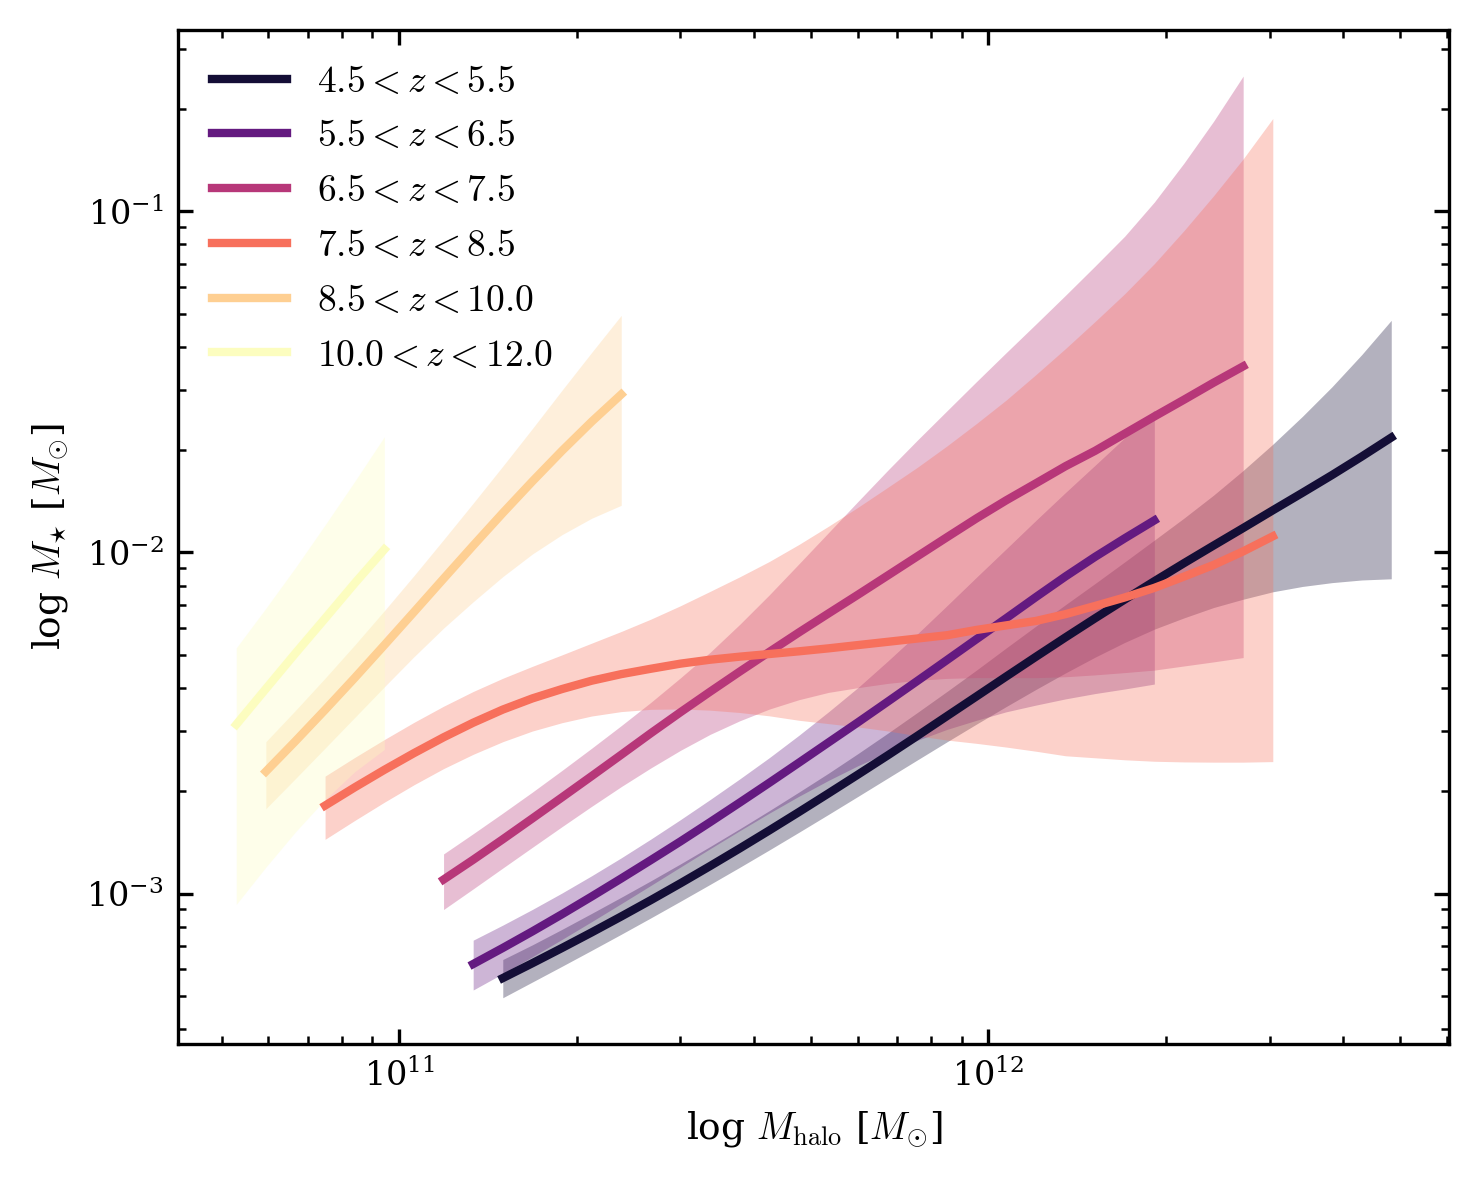

In [3]:
# read in behroozi data for comparison
smmr = np.loadtxt("./data/sm_averages_a1.002310.dat")
loghm = smmr[5:21, 0]  # halo mass
hm = 10**loghm * u.solMass

logSM = smmr[5:21, 7]  # stellar mass
sm = 10 ** logSM[5:21] * u.solMass

SMerr = np.vstack([smmr[5:21, 3], smmr[5:21, 2]])  # error array
logSMHM = smmr[5:21, 10]  # stellar mass / halo mass
SMHMerr = np.vstack([smmr[5:21, 12], smmr[5:21, 11]])  # error array

smhm_behroozi = 10**logSMHM / (Ob0 / Omegam0)
smhm_err_up = 10 ** SMHMerr[1, :]
smhm_err_low = 10 ** SMHMerr[0, :]


# define the redshift bins strings that will make it easier to read z-bins
zbins_str = [
    # "0.2 < z < 0.5",
    # "0.5 < z < 0.8",
    # "0.8 < z < 1.1",
    # "1.1 < z < 1.5",
    # "1.5 < z < 2.0",
    # "2.0 < z < 2.5",
    # "2.5 < z < 3.0",
    # "3.0 < z < 3.5",
    # "3.5 < z < 4.5",
    "4.5 < z < 5.5",
    "5.5 < z < 6.5",
    "6.5 < z < 7.5",
    "7.5 < z < 8.5",
    "8.5 < z < 10.0",
    "10.0 < z < 12.0",
]

## read the table
smf_data = Table.read("./data/Shuntov2024-shmr.ecsv", format="ascii.ecsv")

# define empty dictionaries to store values for each z-bin
Mhalo = {}
Mstar = {}
Mstar_low = {}
Mstar_up = {}

# read for each z-bin
for zb in zbins_str:
    Mhalo[zb] = smf_data[smf_data["Redshift"] == zb]["M_halo"]
    Mstar[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_50"]
    Mstar_low[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_16"]
    Mstar_up[zb] = smf_data[smf_data["Redshift"] == zb]["M_star_84"]


# Create a figure
fig, axs = plt.subplots(1, 1, figsize=(5, 4), dpi=300)
fig.subplots_adjust(hspace=0.00, wspace=1.000)


for i, zb in enumerate(zbins_str):
    smhm_shuntov = np.array(Mstar[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    smhm_shuntov_low = np.array(Mstar_low[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    smhm_shuntov_up = np.array(Mstar_up[zb]) / np.array(Mhalo[zb]) * (Ob0 / Omegam0)
    axs.plot(
        Mhalo[zb],
        smhm_shuntov,
        lw=2,
        alpha=1.0,
        color=plt.cm.magma((i + 0.5) / 5),
        label=f"${zb}$",
    )
    axs.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.32,
        color=plt.cm.magma((i + 0.5) / 5),
    )

# Set axes properties
axs.set_yscale("log")
axs.set_xscale("log")
# axs.set_ylim(1.0e-7, 0.2)
# axs.set_xlim(7.25, 12.2)
axs.set_ylabel(r"log $M_{\star}$ [$M_{\odot}$]")
axs.set_xlabel(r"log $M_{\rm halo}$ [$M_{\odot}$]")
axs.minorticks_on()
axs.legend(frameon=False)
plt.tight_layout()
plt.show()

In [4]:
def custom_mass_loading(mhalo, A=10, alpha=-0.7):
    """mass loading factor as a function of halo mass"""
    return A * (mhalo / (1e10 * u.solMass)) ** alpha


def custom_energy_loading(mhalo, A=0.10, alpha=-0.5):
    """energy loading factor as a function of halo mass"""
    return A * (mhalo / (1e12 * u.solMass)) ** alpha


def run_redshift_grid(observe_at, mhalos, write_to_file=None):
    eta_z = 0.3
    # observe these halos at a given redshift

    # declare a 2d array to store the results
    # each row is a different redshift
    # each column is a different halo mass
    smhm_out = []
    for zidx, z_obs in enumerate(observe_at):
        # get the initial masses of the halos at t_init
        t_init = 0.1  # Gyr
        # get the final time given the observed redshift

        t_final = LCDM.age(z_obs).value  # Gyr
        t_span = (t_init, t_final)  # span of the integration

        mhalo_obs = []
        mstar_obs = []

        # now, get the mass of the halo at z0 which is what we put into the integrator
        for midx, mhalo in enumerate(mhalos[zidx]):
            mhalo_z0 = mhalo_at_z0(mhalo, z_obs) * u.Msun
            eta_m = custom_mass_loading(mhalo)
            eta_e = custom_energy_loading(mhalo)
            print("observing halo with mass {:.2e} at z = {:.2f}".format(mhalo, z_obs))
            print("mass of halo at z=0 is {:.2e}".format(mhalo_z0))
            gridmodel = CGM_regulator(
                mhalo_z0, t_span, eta_m=eta_m, eta_e=eta_e, eta_z=eta_z
            )
            run = gridmodel.run_halo()
            results = gridmodel.get_results()
            m_star = results["m_star"][-1]
            m_halo = results["m_halo"][-1]
            print("** final halo mass = {:.2e}".format(m_halo))
            mhalo_obs.append(m_halo)
            mstar_obs.append(m_star)

        mhalo_obs = np.array(mhalo_obs)
        mstar_obs = np.array(mstar_obs)

        smhm = mstar_obs / (mhalo_obs * (Ob0 / Omegam0))
        print(smhm)
        smhm_out.append(smhm)

    if write_to_file is not None:
        # commma separated string of the redshifts
        z_string_formatted = ",".join([str(i) for i in observe_at])
        mhalos_string_formatted = ",".join([str(i.value) for i in mhalos])
        header_str = (
            "row redshifts = {}"
            "\n"
            "mhalos = {}".format(z_string_formatted, mhalos_string_formatted)
        )

        np.savetxt(write_to_file, smhm_out, header=header_str)

    return smhm_out, mhalos


# %%
# zobs = [12, 11]  # redshifts to observe at
zobs = [12, 11, 10, 9, 8, 7, 6, 5.5, 5]  # redshifts to observe at
# make a unique halo arros for each redshift
mhalos = [
    np.geomspace(1e10, 5e11, 10) * u.Msun,
    np.geomspace(1e10, 5e11, 10) * u.Msun,
    np.geomspace(1e10, 6e11, 10) * u.Msun,
    np.geomspace(1e10, 6e11, 10) * u.Msun,
    np.geomspace(1e10, 6e11, 10) * u.Msun,
    np.geomspace(1e10, 8e12, 10) * u.Msun,
    np.geomspace(1e10, 8e12, 10) * u.Msun,
    np.geomspace(1e10, 1e13, 10) * u.Msun,
    np.geomspace(1e10, 1e13, 10) * u.Msun,
]  # halo mass for each redshift


redshift_variation, _ = run_redshift_grid(
    zobs,
    mhalos,
    write_to_file="./runs/smhm_grid_varying_etaEandetaM_high_z_higher_eta_e.dat",
)

observing halo with mass 1.00e+10 solMass at z = 12.00
mass of halo at z=0 is 1.89e+13 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 12.00 redshift
self.time_interval (0.1, 0.3626642770928055) tstep 1
Initial halo mass (t = 0.10 Gyr) = 2.92e+07 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 2.92e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 3.65e+47 erg


/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 1.01e+10 Msol	Initial halo mass = 2.92e+07 Msol	Final stellar mass = 3.96e+07 Msol	Peak halo scale efficiency = 2.44e-02	Final CGM mass = 3.65e+08 Msol	Final CGM metallicity = 1.99e-02	Final CGM energy = 1.31e+56 erg
_________________________________________
** final halo mass = 1.01e+10
observing halo with mass 1.54e+10 solMass at z = 12.00
mass of halo at z=0 is 4.88e+13 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 12.00 redshift
self.time_interval (0.1, 0.3626642770928055) tstep 1
Initial halo mass (t = 0.10 Gyr) = 3.71e+07 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 3.71e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 4.

/mnt/home/fgarcia/py_venves/camels/lib/python3.9/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Initial halo mass (t = 0.10 Gyr) = 9.24e+07 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 9.24e+07 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 7.87e+47 erg
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 8.91e+10 Msol	Initial halo mass = 9.24e+07 Msol	Final stellar mass = 1.27e+09 Msol	Peak halo scale efficiency = 8.90e-02	Final CGM mass = 5.68e+09 Msol	Final CGM metallicity = 4.37e-02	Final CGM energy = 3.44e+57 erg
_________________________________________
** final halo mass = 8.91e+10
observing halo with mass 1.36e+11 solMass at z = 12.00
mass of halo at z=0 is 1.53e+16 solMass
_________________________________________
Running models from z = 29.69 redshift to z = 12.00 redshift
self.time_interval (0.1, 0.362664277092805

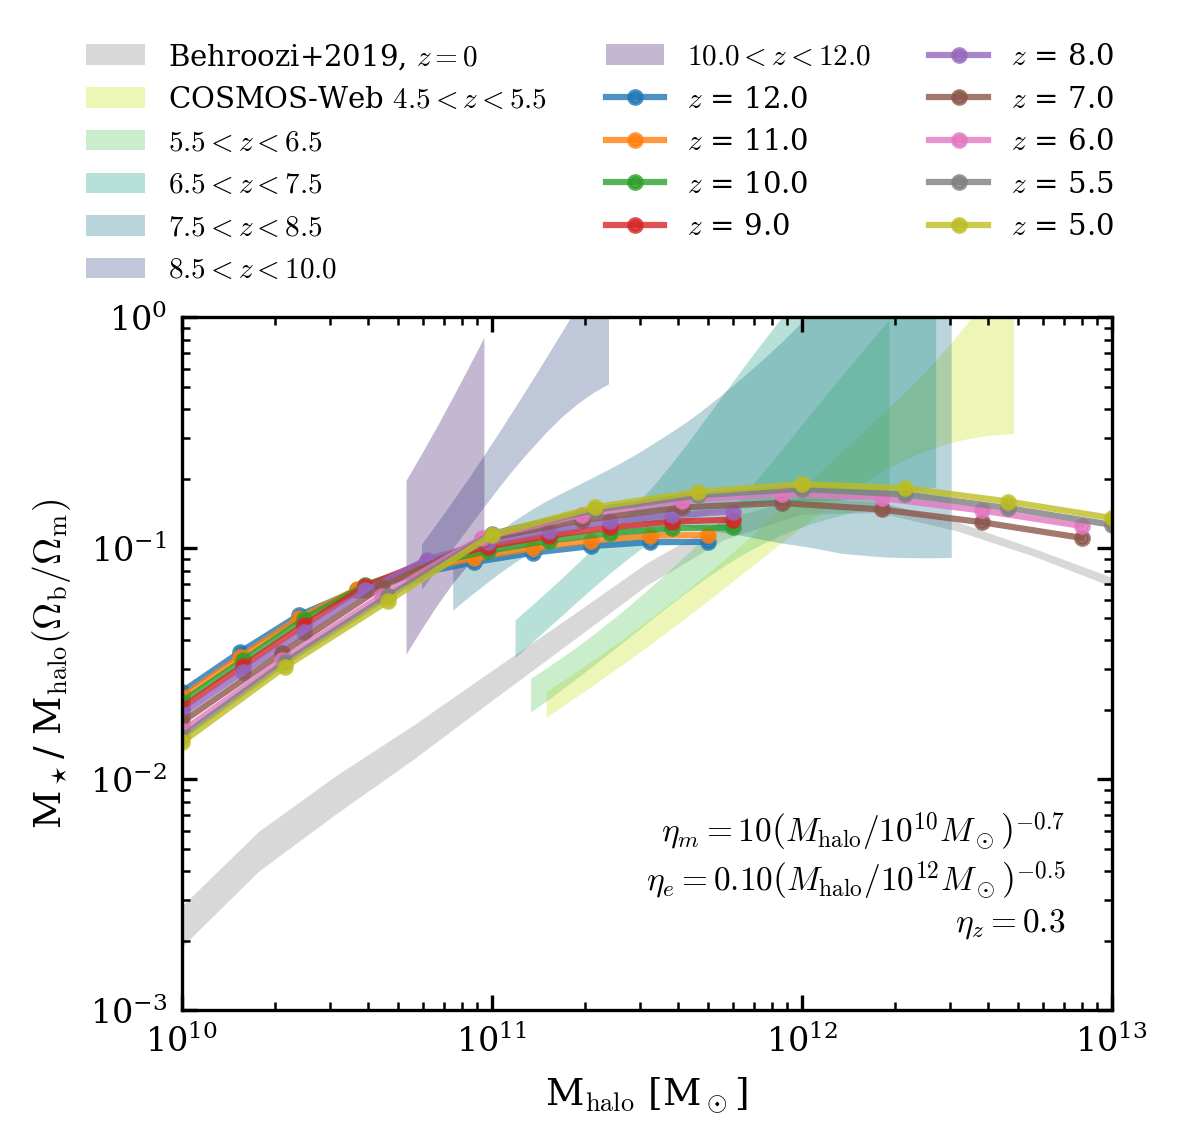

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
# ax.plot(10**loghm, 10**logSMHM, color="k", ls="--")
ax.fill_between(
    10**loghm,
    smhm_behroozi * smhm_err_low,
    smhm_behroozi * smhm_err_up,
    facecolor="grey",
    alpha=0.3,
    label="Behroozi+2019, $z = 0$",
)

for i, zb in enumerate(zbins_str):
    smhm_shuntov = np.array(Mstar[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_low = np.array(Mstar_low[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    smhm_shuntov_up = np.array(Mstar_up[zb]) / (np.array(Mhalo[zb]) * (Ob0 / Omegam0))
    # ax.plot(
    #     Mhalo[zb],
    #     smhm_shuntov,
    #     lw=2,
    #     alpha=1.0,
    #     color=plt.cm.magma((i + 0.5) / len(zbins_str)),
    # )
    label = f"COSMOS-Web ${zb}$" if i == 0 else f"${zb}$"

    ax.fill_between(
        Mhalo[zb],
        smhm_shuntov_low,
        smhm_shuntov_up,
        lw=0,
        alpha=0.32,
        color=plt.cm.viridis_r((i + 0.5) / len(zbins_str)),
        label=label,
    )

for i, smhm_model in enumerate(redshift_variation):
    ax.plot(
        mhalos[i],
        smhm_model,
        markersize=3,
        marker="o",
        label=r"$z$ = {:.1f}".format(zobs[i]),
        alpha=0.8,
    )

# model text
model_text = (
    r"$\eta_m = 10 \left( M_{\rm halo} / 10^{10} M_\odot \right)^{-0.7}$"
    + "\n"
    + r"$\eta_e = 0.10 \left( M_{\rm halo} / 10^{12} M_\odot \right)^{-0.5}$"
    + "\n"
    + r"$\eta_z = 0.3$"
)
ax.text(
    0.95,
    0.1,
    model_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="bottom",
    horizontalalignment="right",
)
ax.set(
    xlabel=r"M$_{\rm halo}$ [M$_\odot$]",
    ylabel=r"M$_\star$/ M$_{\rm halo} (\Omega_{\rm b}/\Omega_{\rm m})$",
    yscale="log",
    xscale="log",
    xlim=(1e10, 1e13),
    ylim=(1e-3, 1),
)
ax.legend(
    bbox_to_anchor=(0.45, 1.01), loc="lower center", ncol=3, frameon=False, fontsize=7
)

plt.savefig(
    "./figures/smhm_grid_varying_etaEandetaM_extended_fakhouri.png",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.1,
)
plt.show()

_________________________________________
Running models from z = 29.69 redshift to z = 5.61 redshift
self.time_interval (0.1, 1) tstep 0.001
Initial halo mass (t = 0.10 Gyr) = 5.39e+05 Msol
> initial values ISM gas mass = 1.00e+03 Msol	Stellar mass = 1.00e+03 Msol	CGM mass = 1.00e+03 Msol	Metal mass = 1.34e-02 Msol	CGM metallicity = 0.0010 (Zsun)	Halo mass = 5.39e+05 Msol	ISM wind energy = 1.00e+03 erg	CGM cooling energy = 1.00e+03 erg	CGM out energy = 1.00e+03 erg	CGM in energy = 1.00e+03 erg	CGM energy = 1.30e+46 erg
*** Solution status: 0 (0: succes, -1: step failed, 1: termination )
Final halo mass = 9.51e+07 Msol	Initial halo mass = 5.39e+05 Msol	Final stellar mass = 1.35e+05 Msol	Peak halo scale efficiency = 1.16e-02	Final CGM mass = 1.91e+05 Msol	Final CGM metallicity = 2.30e-02	Final CGM energy = 8.84e+51 erg
_________________________________________


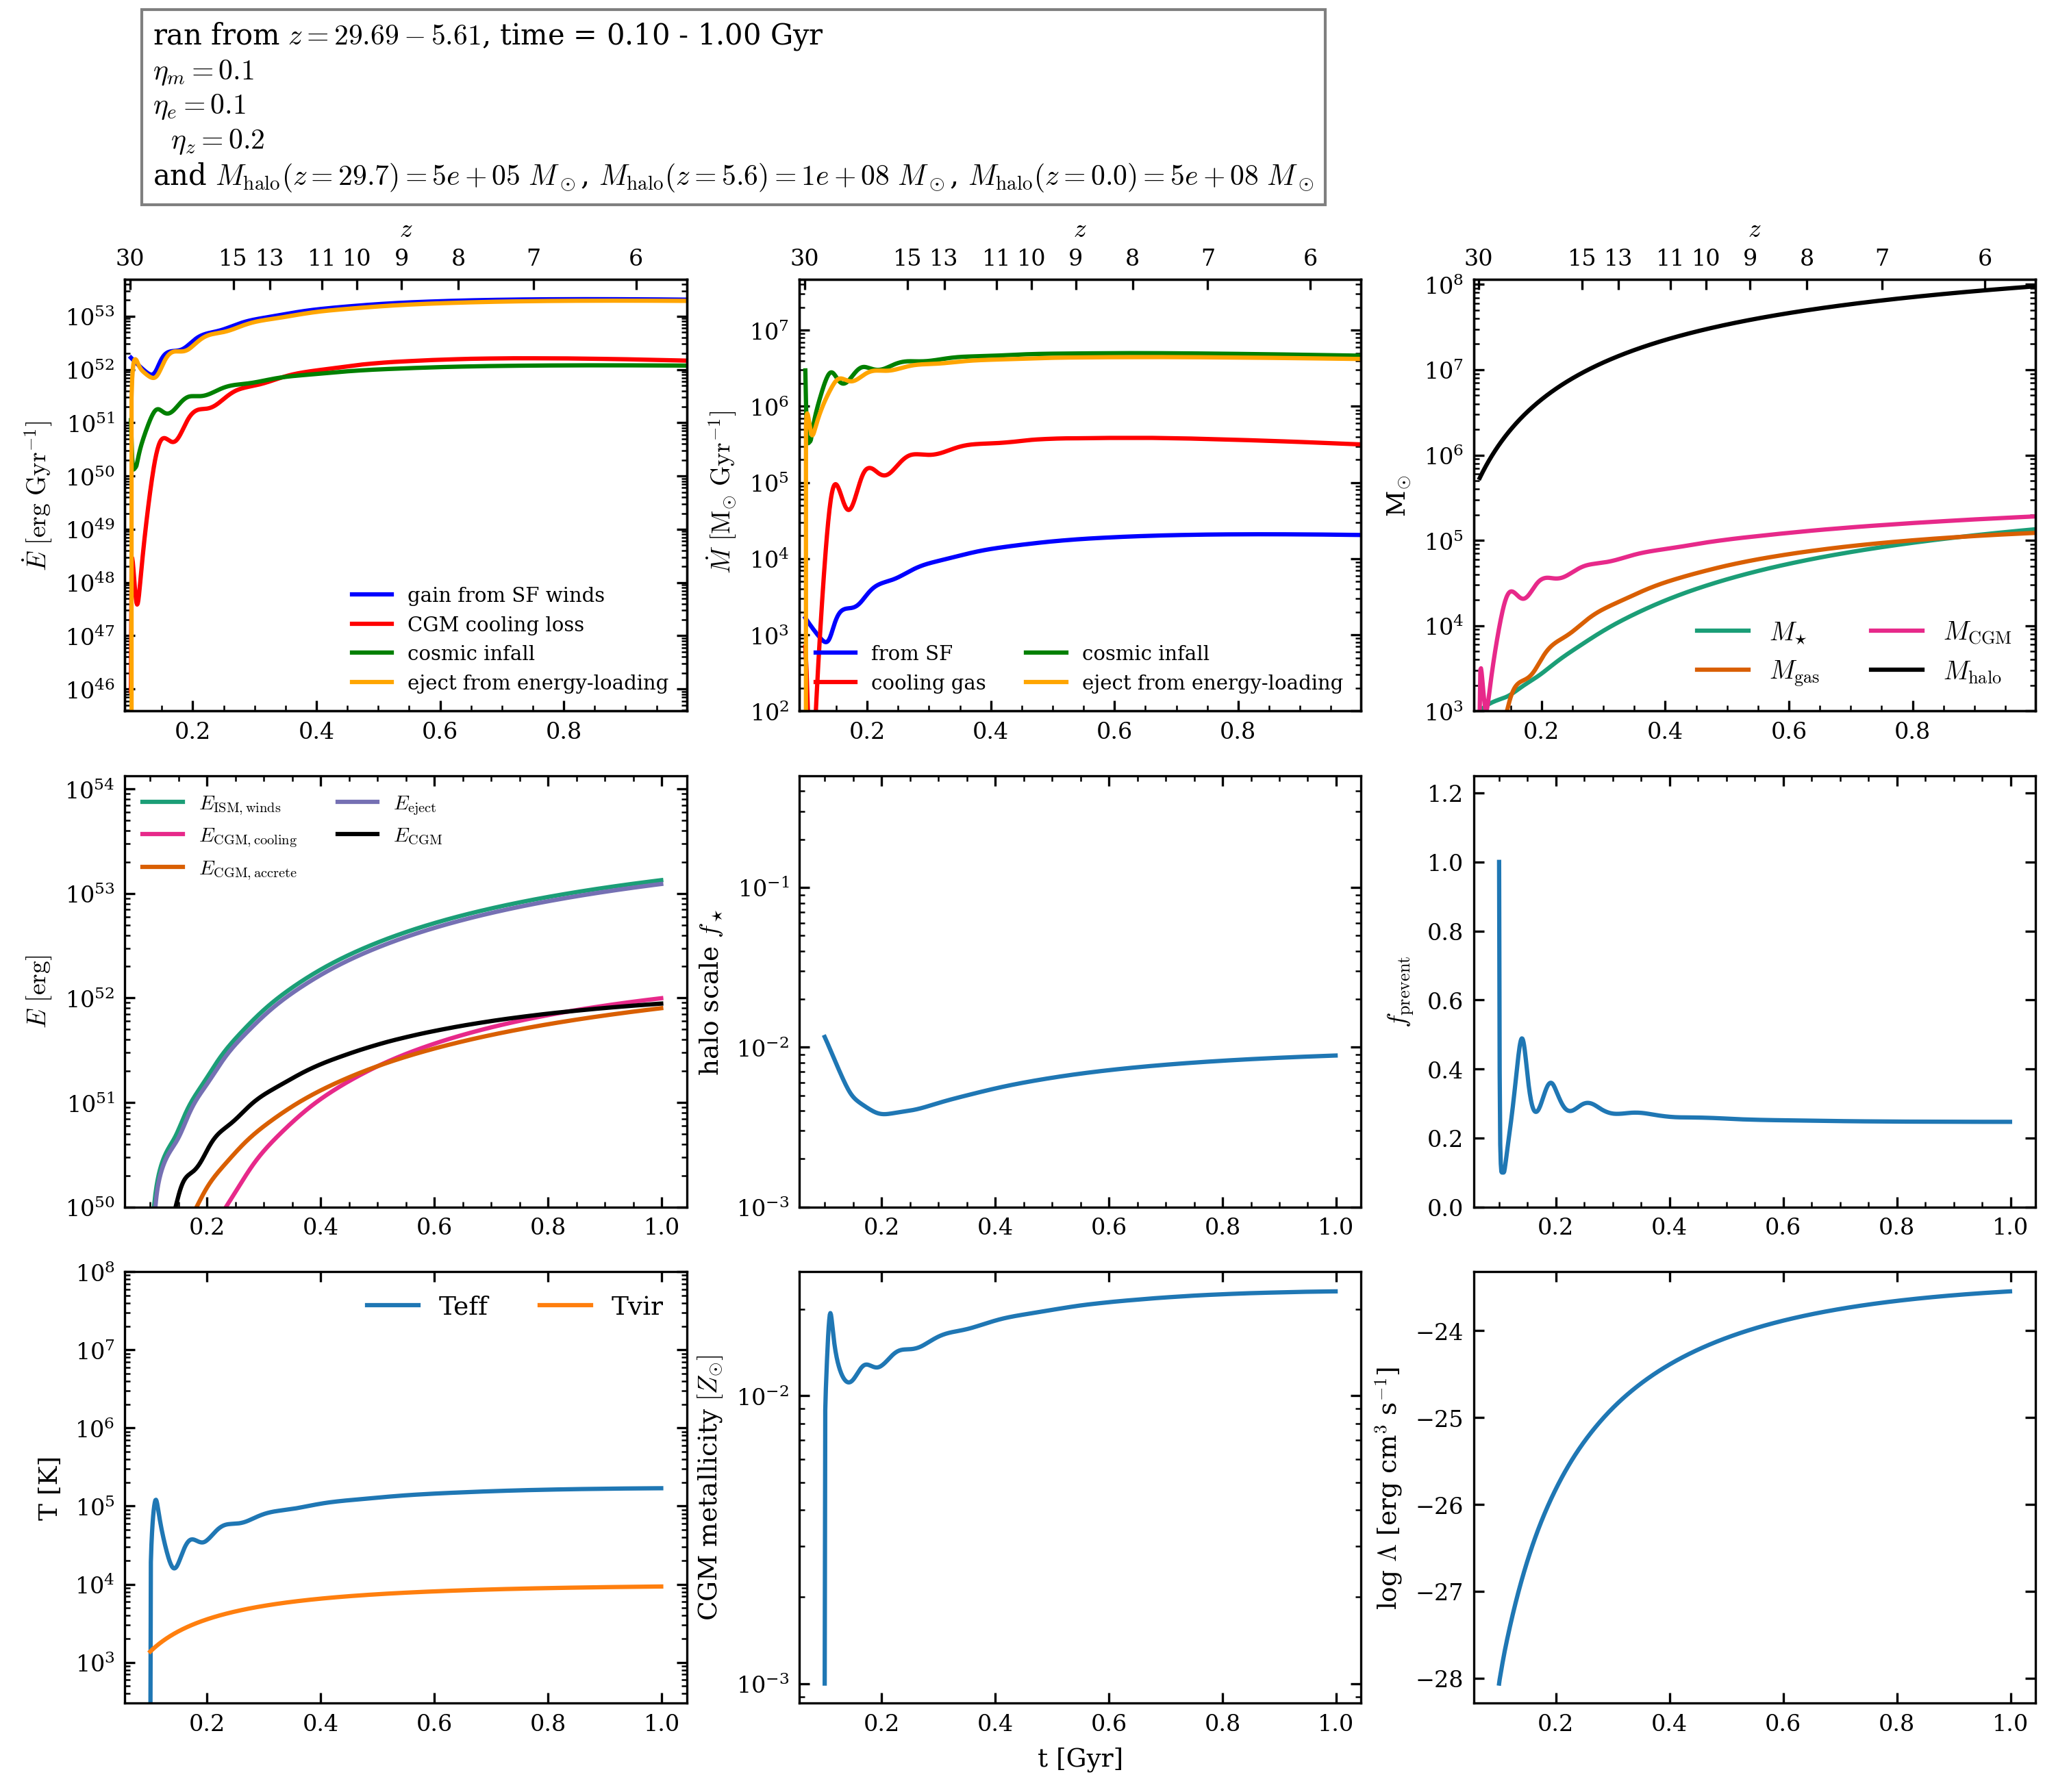

In [6]:
# run a test model
mhalo_z0 = 5e8 * u.Msun
t_span = (0.1, 1)  # gyrs
eta_m = 0.1
eta_e = 0.1
eta_z = 0.2
mhalo_t0 = 5e7 * u.Msun
model = CGM_regulator(
    mhalo_z0, t_span, tstep=0.001, eta_m=eta_m, eta_e=eta_e, eta_z=eta_z
)
run = model.run_halo()
results = model.get_results()
derived = model.get_derived_quantities()
plot_halo_diagnostics(results, derived, eta_m=eta_m, eta_e=eta_e, eta_z=eta_z)